#### **Pipeline**

raw photos → detect + align + crop → crops/ + manifest.json → embed crops (skip detector) → index

In [1]:
import os, json, cv2
import numpy as np
from pathlib import Path
from deepface import DeepFace

26-10-03 03:49:50 - ⚠️ 
 ⚠️ DEPRECATION WARNING:
 Running 'pip install deepface' alone will no longer be sufficient and will
 NOT install a default backend in an upcoming major release.

 Currently, TensorFlow is included by default, but this behavior will be deprecated.
 Please explicitly specify your preferred backend engine when installing:

   -> pip install deepface[tensorflow]
   -> pip install deepface[pytorch]

 Otherwise, you will encounter 'module not found' errors.



I0000 00:00:1790979590.454672  180372 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790979590.455175  180372 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790979591.620122  180372 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790979591.620382  180372 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
DATABASE_DIR = Path("../datasets/raw_data/")
CROPS_DIR = Path("../datasets/dataset_deepface/")
MANIFEST = Path("../datasets/results/crops_manifest_deepface.json")

DETECTOR = "yunet"          # or "retinaface" for better quality
EXTS = (".jpg", ".jpeg", ".png")
MIN_FACE_PX, MIN_CONF = 40, 0.90

#### **Step A: Create the crop dataset (one time)**

In [3]:
CROPS_DIR.mkdir(parents=True, exist_ok=True)
manifest = json.loads(MANIFEST.read_text()) if MANIFEST.exists() else {}

# Collect all images, keeping paths relative to DATABASE_DIR
all_paths = sorted(p for p in DATABASE_DIR.rglob("*") if p.suffix.lower() in EXTS)
done_sources = {m["source"] for m in manifest.values()}
todo = [p for p in all_paths if str(p) not in done_sources]
print(f"{len(all_paths)} images, {len(todo)} to process")

for n, path in enumerate(todo, 1):
    rel = path.relative_to(DATABASE_DIR)          # e.g. personA/sub/img1.jpg
    try:
        faces = DeepFace.extract_faces(
            str(path), detector_backend=DETECTOR, align=True,
            enforce_detection=True, expand_percentage=10)
    except Exception:
        faces = []

    kept = 0
    for f in faces:
        fa, conf = f["facial_area"], f.get("confidence", 1.0)
        if fa["w"] < MIN_FACE_PX or fa["h"] < MIN_FACE_PX or conf < MIN_CONF:
            continue

        # First face keeps the original name; extra faces get a suffix
        stem = rel.stem if kept == 0 else f"{rel.stem}__{kept}"
        out_rel = rel.with_name(stem + ".jpg")    # same subfolders, same name
        out_path = CROPS_DIR / out_rel
        out_path.parent.mkdir(parents=True, exist_ok=True)

        img = (f["face"] * 255).clip(0, 255).astype(np.uint8)
        cv2.imwrite(str(out_path), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

        # Manifest key is the crop's relative path (posix style for portability)
        manifest[out_rel.as_posix()] = {
            "source": str(path),
            "source_rel": rel.as_posix(),
            "box": [fa["x"], fa["y"], fa["w"], fa["h"]],
            "conf": float(conf),
        }
        kept += 1

    if n % 25 == 0:
        MANIFEST.write_text(json.dumps(manifest))
        print(f"{n}/{len(todo)}")

MANIFEST.write_text(json.dumps(manifest))
print(len(manifest), "face crops saved in", CROPS_DIR.resolve())

513 images, 215 to process
25/215
50/215
75/215
100/215
125/215
150/215
175/215
200/215
298 face crops saved in /home/rakesh/GitRepo/Object-Detection-Models/datasets/dataset_deepface


#### **Find photos with no face**

In [12]:
have = {DATABASE_DIR for m in manifest.values()}
missing = [p for p in all_paths if p.relative_to(DATABASE_DIR).as_posix() not in have]
print(len(missing), "missing")

reasons = {}
for p in missing:
    try:
        faces = DeepFace.extract_faces(str(p), detector_backend=DETECTOR,
                                       align=True, enforce_detection=True)
        info = [(f["facial_area"]["w"], f["facial_area"]["h"],
                 round(f.get("confidence", 0), 2)) for f in faces]
        reasons[p] = ("FILTERED", info)       # found, but my size/conf filter dropped it
    except Exception:
        reasons[p] = ("NOT DETECTED", None)   # detector found nothing

for p, (why, info) in list(reasons.items())[:20]:
    print(why, p.relative_to(DATABASE_DIR), info or "")

513 missing
FILTERED 1. Vimala Kumari/img0001.jpg [(1285, 1675, 0.93)]
FILTERED 1. Vimala Kumari/img0002.jpg [(1398, 1915, 0.93)]
FILTERED 1. Vimala Kumari/img0003.jpg [(1096, 1423, 0.93)]
FILTERED 1. Vimala Kumari/img0004.jpg [(1033, 1348, 0.93)]
FILTERED 10. Nidhi/img0001.jpg [(1108, 1512, 0.93)]
FILTERED 10. Nidhi/img0002.jpg [(1134, 1512, 0.92)]
FILTERED 10. Nidhi/img0003.jpg [(1096, 1436, 0.91)]
FILTERED 10. Nidhi/img0004.jpg [(1121, 1486, 0.93)]
FILTERED 2. Rakesh Ranjan/img0001.jpg [(970, 1222, 0.94)]
FILTERED 2. Rakesh Ranjan/img0002.jpg [(907, 1234, 0.94)]
FILTERED 2. Rakesh Ranjan/img0003.jpg [(1184, 1562, 0.91)]
NOT DETECTED 2. Rakesh Ranjan/img0004.jpg 
FILTERED 2. Rakesh Ranjan/img0005.jpg [(957, 1285, 0.92)]
FILTERED 2. Rakesh Ranjan/img0006.jpg [(995, 1297, 0.92)]
FILTERED 2. Rakesh Ranjan/img0007.jpg [(806, 1045, 0.94)]
FILTERED 2. Rakesh Ranjan/img0008.jpg [(831, 1071, 0.93)]
FILTERED 2. Rakesh Ranjan/img0009.jpg [(768, 995, 0.94)]
FILTERED 2. Rakesh Ranjan/img0010.jpg

#### **Fallback pass with a stronger detector**

In [13]:
FALLBACK = "retinaface"       # or "mtcnn"
MIN_FACE_PX, MIN_CONF = 25, 0.80

for n, path in enumerate(missing, 1):
    rel = path.relative_to(DATABASE_DIR)
    try:
        faces = DeepFace.extract_faces(str(path), detector_backend=FALLBACK,
                                       align=True, enforce_detection=True,
                                       expand_percentage=10)
    except Exception:
        print("still no face:", rel)
        continue

    kept = 0
    for f in faces:
        fa, conf = f["facial_area"], f.get("confidence", 1.0)
        if fa["w"] < MIN_FACE_PX or fa["h"] < MIN_FACE_PX or conf < MIN_CONF:
            continue
        stem = rel.stem if kept == 0 else f"{rel.stem}__{kept}"
        out_rel = rel.with_name(stem + ".jpg")
        out_path = CROPS_DIR / out_rel
        out_path.parent.mkdir(parents=True, exist_ok=True)
        img = (f["face"] * 255).clip(0, 255).astype(np.uint8)
        cv2.imwrite(str(out_path), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        manifest[out_rel.as_posix()] = {
            "source": str(path), "source_rel": rel.as_posix(),
            "box": [fa["x"], fa["y"], fa["w"], fa["h"]],
            "conf": float(conf), "detector": FALLBACK,
        }
        kept += 1
    print(f"{n}/{len(missing)}", rel, "->", kept, "face(s)")

MANIFEST.write_text(json.dumps(manifest))

1/513 1. Vimala Kumari/img0001.jpg -> 1 face(s)
2/513 1. Vimala Kumari/img0002.jpg -> 1 face(s)
3/513 1. Vimala Kumari/img0003.jpg -> 1 face(s)
4/513 1. Vimala Kumari/img0004.jpg -> 1 face(s)
5/513 10. Nidhi/img0001.jpg -> 1 face(s)
6/513 10. Nidhi/img0002.jpg -> 1 face(s)
7/513 10. Nidhi/img0003.jpg -> 1 face(s)
8/513 10. Nidhi/img0004.jpg -> 1 face(s)
9/513 2. Rakesh Ranjan/img0001.jpg -> 1 face(s)
10/513 2. Rakesh Ranjan/img0002.jpg -> 1 face(s)
11/513 2. Rakesh Ranjan/img0003.jpg -> 1 face(s)
12/513 2. Rakesh Ranjan/img0004.jpg -> 1 face(s)
13/513 2. Rakesh Ranjan/img0005.jpg -> 1 face(s)
14/513 2. Rakesh Ranjan/img0006.jpg -> 2 face(s)
15/513 2. Rakesh Ranjan/img0007.jpg -> 1 face(s)
16/513 2. Rakesh Ranjan/img0008.jpg -> 1 face(s)
17/513 2. Rakesh Ranjan/img0009.jpg -> 1 face(s)
18/513 2. Rakesh Ranjan/img0010.jpg -> 1 face(s)
19/513 2. Rakesh Ranjan/img0011.jpg -> 1 face(s)
20/513 2. Rakesh Ranjan/img0012.jpg -> 1 face(s)
21/513 2. Rakesh Ranjan/img0013.jpg -> 1 face(s)
22/513 2

143296

#### **Build the index from crops**

In [14]:
import pickle
from deepface import DeepFace

MODEL = "Facenet512"
INDEX_PATH = Path(f"../datasets/results/index_{MODEL}_deepface.pkl")

index = pickle.load(open(INDEX_PATH, "rb")) if INDEX_PATH.exists() else {}
for name, meta in manifest.items():
    if name in index or not (CROPS_DIR / name).exists():
        continue
    rep = DeepFace.represent(str(CROPS_DIR / name), model_name=MODEL,
                             detector_backend="skip", enforce_detection=False)[0]
    index[name] = {"emb": rep["embedding"], **meta}

pickle.dump(index, open(INDEX_PATH, "wb"))
print(len(index), "embeddings")

518 embeddings


#### **Search with a raw query image**

In [16]:
import pickle
import numpy as np
import cv2
from pathlib import Path
from deepface import DeepFace

DATABASE_DIR = Path("../datasets/raw_data/")
QUERY_IMAGE = "../datasets/images/Tejrit.jpg"
MODEL = "Facenet512"
INDEX_PATH = Path(f"../datasets/results/index_{MODEL}_deepface.pkl")

QUERY_DETECTOR = "retinaface"   # strongest available, since this one face drives the search
EXPAND = 10                     # must match expand_percentage used in Step A
QUERY_FACE_IDX = None           # None = largest face; or 0, 1, ... to force one

STRICT_THRESHOLD = 0.30         # Facenet512 cosine. If you switch to ArcFace, use ~0.68
TOP_K = 12

def unit(v):
    v = np.asarray(v, dtype=np.float32)
    return v / np.linalg.norm(v, axis=-1, keepdims=True)

# --- Load the index (keys are crop paths relative to the crops folder)
with open(INDEX_PATH, "rb") as f:
    index = pickle.load(f)

names = list(index.keys())
vecs = unit(np.array([index[n]["emb"] for n in names]))
print(f"{len(names)} face crops in index")

# --- Detect and crop the face(s) in the raw query image
q_faces = DeepFace.extract_faces(QUERY_IMAGE, detector_backend=QUERY_DETECTOR,
                                 align=True, enforce_detection=True,
                                 expand_percentage=EXPAND)
print(f"{len(q_faces)} face(s) found in query image")

if QUERY_FACE_IDX is None:
    q_face = max(q_faces, key=lambda f: f["facial_area"]["w"] * f["facial_area"]["h"])
else:
    q_face = q_faces[QUERY_FACE_IDX]

qa = q_face["facial_area"]
q_box = (qa["x"], qa["y"], qa["w"], qa["h"])

# --- Embed the query crop the same way the database crops were embedded
crop = (q_face["face"] * 255).clip(0, 255).astype(np.uint8)
crop_bgr = cv2.cvtColor(crop, cv2.COLOR_RGB2BGR)
# Round-trip through JPEG so it matches the saved database crops
crop_bgr = cv2.imdecode(cv2.imencode(".jpg", crop_bgr)[1], cv2.IMREAD_COLOR)

q = unit(DeepFace.represent(crop_bgr, model_name=MODEL,
                            detector_backend="skip",
                            enforce_detection=False)[0]["embedding"])

# --- Rank by cosine distance, keeping the best crop per source photo
dist = 1 - vecs @ q
order = np.argsort(dist)

seen, matches = set(), []
for i in order:
    meta = index[names[i]]
    src_rel = meta["source_rel"]
    if src_rel in seen:
        continue
    seen.add(src_rel)
    matches.append({
        "crop": names[i],
        "dist": float(dist[i]),
        "src_path": DATABASE_DIR / src_rel,   # portable, built from source_rel
        "box": tuple(meta["box"]),
    })
    if len(matches) >= TOP_K:
        break

n_strict = sum(m["dist"] < STRICT_THRESHOLD for m in matches)
print(f"{n_strict} strict matches (< {STRICT_THRESHOLD}); showing top {len(matches)}")

518 face crops in index
1 face(s) found in query image
12 strict matches (< 0.3); showing top 12


#### **Plot with face boxes**

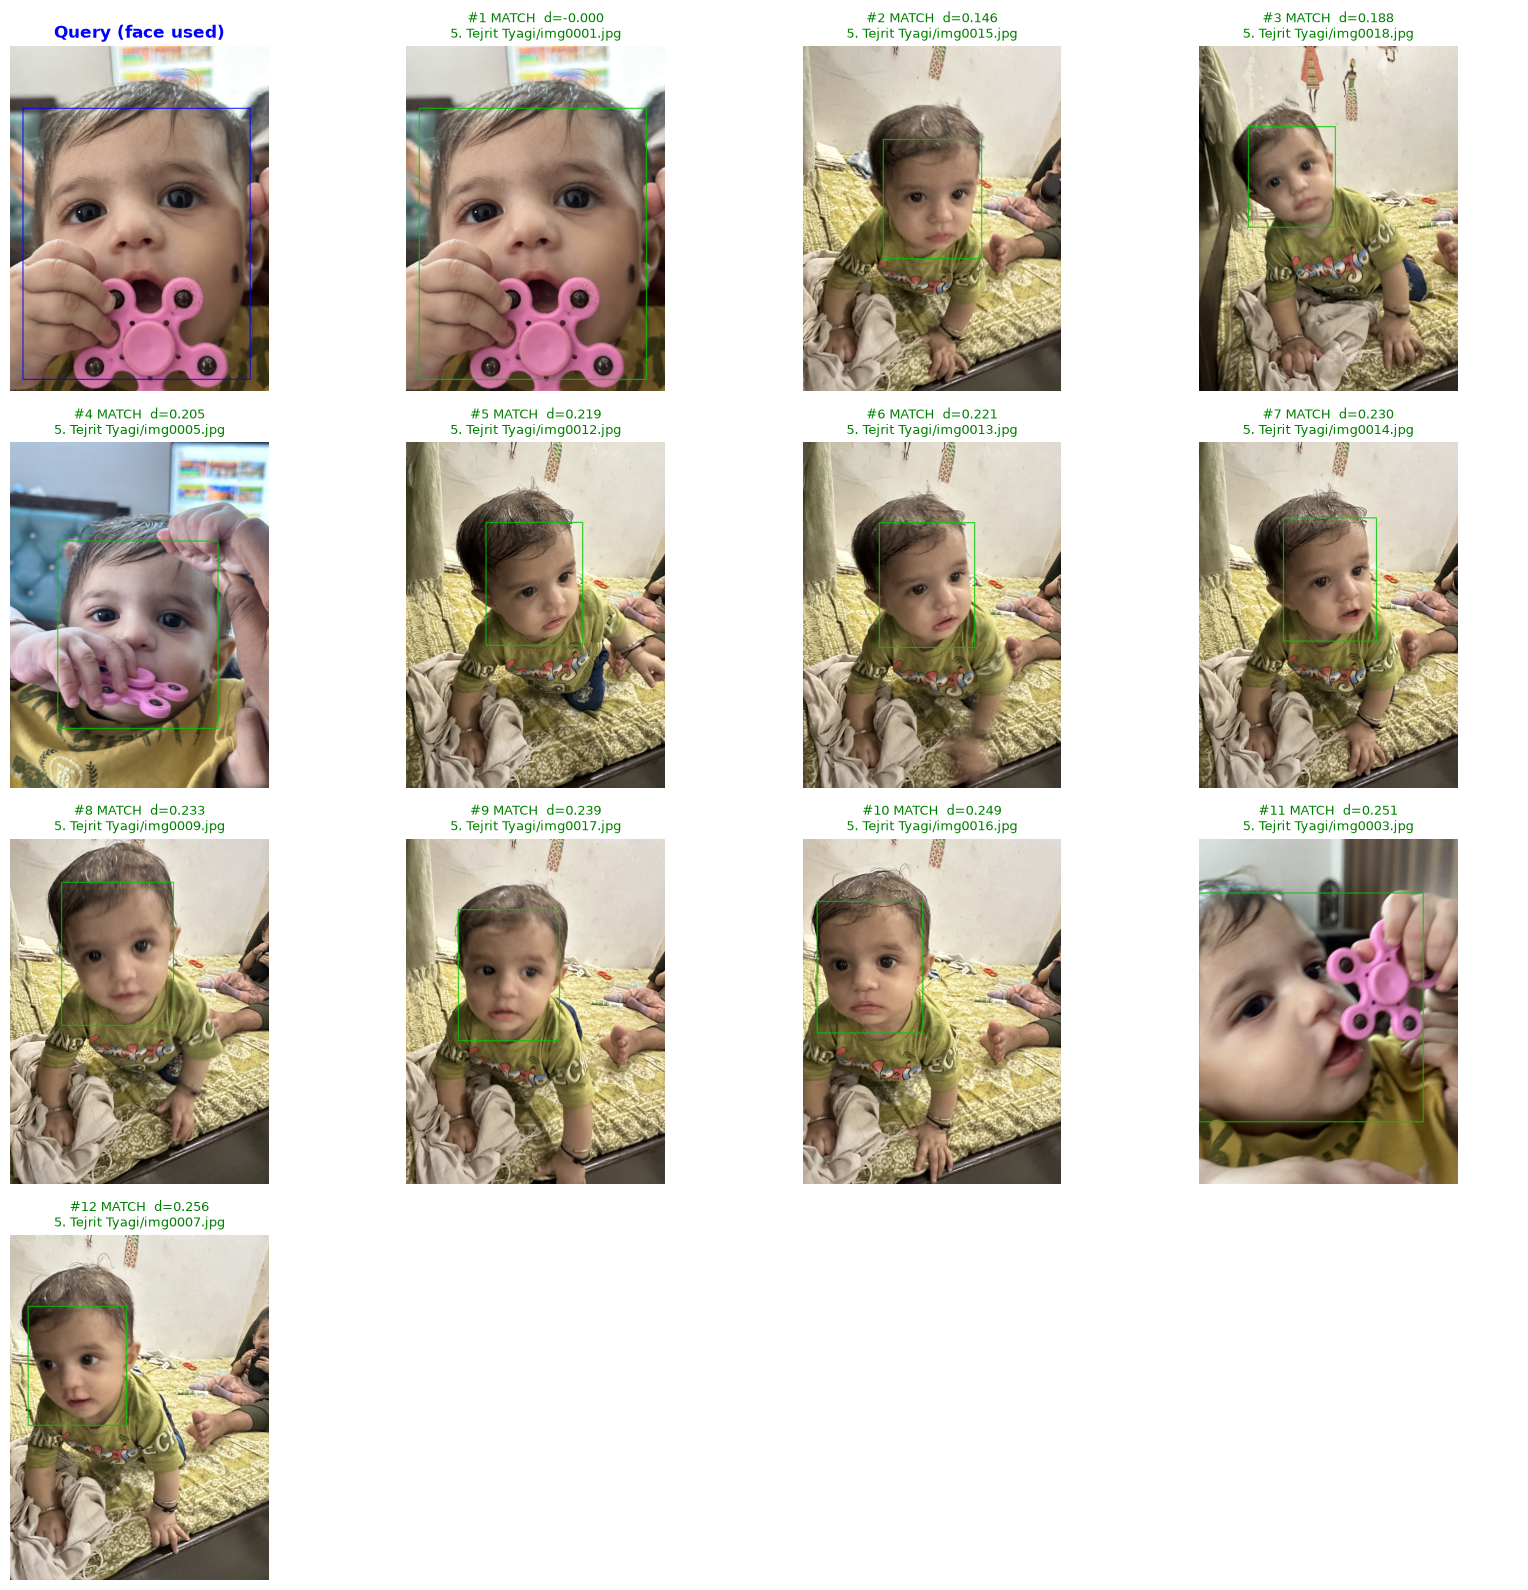

In [17]:
import math
import matplotlib.pyplot as plt

def load_with_box(path, box, color):
    img = cv2.imread(str(path))
    if img is None:
        raise FileNotFoundError(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    x, y, w, h = box
    t = max(2, img.shape[1] // 300)
    cv2.rectangle(img, (x, y), (x + w, y + h), color, t)
    return img

cols = 4
rows = math.ceil((1 + len(matches)) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()

axes[0].imshow(load_with_box(QUERY_IMAGE, q_box, (0, 0, 255)))
axes[0].set_title("Query (face used)", color="blue", fontweight="bold")

for i, m in enumerate(matches, 1):
    good = m["dist"] < STRICT_THRESHOLD
    folder = Path(m["crop"]).parent.as_posix()
    axes[i].imshow(load_with_box(m["src_path"], m["box"],
                                 (0, 200, 0) if good else (255, 0, 0)))
    axes[i].set_title(
        f"#{i} {'MATCH' if good else 'weak'}  d={m['dist']:.3f}\n"
        f"{folder}/{m['src_path'].name[:18]}",
        fontsize=9, color="green" if good else "red")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

#### **Embed all crops, remove duplicates, then save the index**

In [18]:
import json, pickle
import numpy as np
from pathlib import Path
from deepface import DeepFace

MODEL = "Facenet512"
CROPS_DIR = Path("../datasets/dataset_deepface")
MANIFEST = Path("../datasets/results/crops_manifest_deepface.json")
EMB_PATH = Path(f"../datasets/results/emb_all_{MODEL}_deepface.pkl")    # every crop, before dedup
INDEX_PATH = Path(f"../datasets/results/index_{MODEL}_deepface.pkl")    # final, deduplicated

DUP_THRESHOLD = 0.05      # cosine distance below this = same image
SCOPE = "global"          # "global": across all folders, "folder": only within the same folder

manifest = json.loads(MANIFEST.read_text())

# 1) Embed every crop once (cached, resumable)
emb = pickle.load(open(EMB_PATH, "rb")) if EMB_PATH.exists() else {}
for n, name in enumerate(manifest, 1):
    if name in emb or not (CROPS_DIR / name).exists():
        continue
    rep = DeepFace.represent(str(CROPS_DIR / name), model_name=MODEL,
                             detector_backend="skip", enforce_detection=False)[0]
    emb[name] = rep["embedding"]
    if n % 100 == 0:
        pickle.dump(emb, open(EMB_PATH, "wb"))
pickle.dump(emb, open(EMB_PATH, "wb"))
print(len(emb), "crops embedded")

# 2) Greedy deduplication
def unit(v):
    v = np.asarray(v, dtype=np.float32)
    return v / np.linalg.norm(v)

index = {}
groups = {}   # group key -> (list of kept names, list of kept unit vectors)

for name in sorted(emb):
    if not (CROPS_DIR / name).exists():        # you deleted this crop manually
        continue
    v = unit(emb[name])
    g = Path(name).parent.as_posix() if SCOPE == "folder" else ""
    kept_names, kept_vecs = groups.setdefault(g, ([], []))

    if kept_vecs:
        d = 1 - np.array(kept_vecs) @ v
        j = int(np.argmin(d))
        if d[j] < DUP_THRESHOLD:
            # duplicate: don't add it, but remember it under the kept entry
            index[kept_names[j]]["dupes"].append(
                {"crop": name, "source_rel": manifest[name]["source_rel"], "dist": float(d[j])})
            continue

    index[name] = {"emb": emb[name], "dupes": [], **manifest[name]}
    kept_names.append(name)
    kept_vecs.append(v)

n_dupes = sum(len(e["dupes"]) for e in index.values())
print(f"{len(index)} kept, {n_dupes} duplicates skipped")
pickle.dump(index, open(INDEX_PATH, "wb"))

FileNotFoundError: [Errno 2] No such file or directory: '../datasets/results/crops_manifest_deepface.json'

In [19]:
MANIFEST

PosixPath('../datasets/results/crops_manifest_deepface.json')